# IEDB MHC Ligand exploration

Exploring the IEDB MHC-ligand (MHC-presentation) export: how many unique **MHC class I** and **class II** epitopes there are, and how they are distributed across source organisms.

## Data source

Downloaded from: **https://www.iedb.org/database_export_v3.php**

File: **`mhc_ligand_full`** (single_file.zip) (multi_file.zip) → `IEDB/mhc_ligand_full.csv`

Notes:
- The CSV has a **two-row header** (a category row above the column-name row), so we skip both rows and select columns by position.
- The file is ~8.8 GB, so we **stream it in chunks** and keep only the few columns we need.
- "Epitope" here = the linear peptide sequence (`Epitope → Name`). Organism rollup uses `Epitope → Species` (species level) rather than the strain-level `Source Organism`.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

CSV = "IEDB/mhc_ligand_full.csv"

In [ ]:

# Columns selected by position (0-based) from the 112-column file:
USECOLS = [11, 23, 25, 111]
NAMES   = ["peptide", "source_organism", "species", "mhc_class"]

## 1. Stream the file and tally

For each chunk we count records per MHC class and collect the **distinct** `(class, peptide, species)` triples so we can later count unique epitopes and their organism distribution without holding the whole file in memory.

In [2]:
record_counts = Counter()      # records per MHC class
seen = set()                   # distinct (mhc_class, peptide, species)
n_rows = 0

reader = pd.read_csv(CSV, header=None, skiprows=2, usecols=USECOLS, names=NAMES,
                     dtype=str, chunksize=200_000, low_memory=False)

for ch in reader:
    n_rows += len(ch)
    record_counts.update(ch["mhc_class"].fillna("(none)"))
    ch = ch.dropna(subset=["peptide"])
    ch["species"] = ch["species"].fillna("(unknown)")
    ch["mhc_class"] = ch["mhc_class"].fillna("(none)")
    seen.update(map(tuple, ch[["mhc_class", "peptide", "species"]].itertuples(index=False, name=None)))
    print(f"  processed {n_rows:,} rows | distinct (class,peptide,species): {len(seen):,}", end="\r")

print(f"\nDone. Total records: {n_rows:,}")
print("\nRecords per MHC class:")
for k, v in record_counts.most_common():
    print(f"  {k:>15}: {v:,}")

  processed 5,571,576 rows | distinct (class,peptide,species): 1,744,308
Done. Total records: 5,571,576

Records per MHC class:
                I: 3,643,766
               II: 1,918,444
    non classical: 9,366


In [3]:
# Build a tidy table of distinct (class, peptide, species)
u = pd.DataFrame(seen, columns=["mhc_class", "peptide", "species"])
print("distinct (class, peptide, species) rows:", len(u))
u.head()

distinct (class, peptide, species) rows: 1744308


,mhc_class,peptide,species
0,II,SRGFAFVYFENVDDA,Homo sapiens
1,II,KATFLEDV,Homo sapiens
2,I,RMVLSAFDER,Influenza A virus
3,II,QPVYPMSQLSFDRILK + OX(M6),Homo sapiens
4,I,QLIISSALK,Homo sapiens


In [29]:
## read iedb_mhc_ligand_unique.csv to get the species IRI column (26) for later taxonomy use
u = pd.read_csv("/lustre/scratch126/gengen/teams_v2/marks/dp31/tcr-bench/IEDB/iedb_mhc_ligand_unique.csv")

## 2. Unique epitopes per MHC class

Unique epitope (peptide) sequences per MHC class:
mhc_class
I                1031193
II                660628
non classical       5738

Overall unique peptides (any class): 1642589


/tmp/ipykernel_2879310/3789614034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=focus.index, y=focus.values, ax=ax,


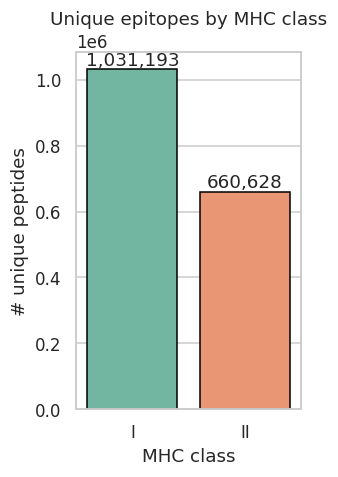

In [32]:
uniq_pep = u.groupby("mhc_class")["peptide"].nunique().sort_values(ascending=False)
print("Unique epitope (peptide) sequences per MHC class:")
print(uniq_pep.to_string())
print("\nOverall unique peptides (any class):", u["peptide"].nunique())

focus = uniq_pep[uniq_pep.index.isin(["I", "II"])]
fig, ax = plt.subplots(figsize=(3, 4.5))
sns.barplot(x=focus.index, y=focus.values, ax=ax, 
            edgecolor="black", linewidth=1,
            palette="Set2")
for i, v in enumerate(focus.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set(title="Unique epitopes by MHC class", xlabel="MHC class", ylabel="# unique peptides")
plt.tight_layout(); plt.show()

## 3. Distribution across source organisms (top organisms)

Counting **unique epitopes per species**, separately for class I and class II. Kept high-level: top 20 organisms per class.

In [33]:
TOP = 20

def top_species(cls):
    s = (u[u["mhc_class"] == cls]
         .groupby("species")["peptide"].nunique()
         .sort_values(ascending=False))
    return s

for cls in ["I", "II"]:
    s = top_species(cls)
    print(f"MHC class {cls}: {len(s):,} distinct source species; top 5:")
    print(s.head(5).to_string(), "\n")

MHC class I: 593 distinct source species; top 5:
species
Homo sapiens         725186
unidentified         122951
Mus musculus          67067
Rattus norvegicus     38173
(unknown)             28254 

MHC class II: 250 distinct source species; top 5:
species
Homo sapiens                                       472141
(unknown)                                           83417
Bos taurus                                          50058
Mus musculus                                        29715
Severe acute respiratory syndrome coronavirus 2     11081 



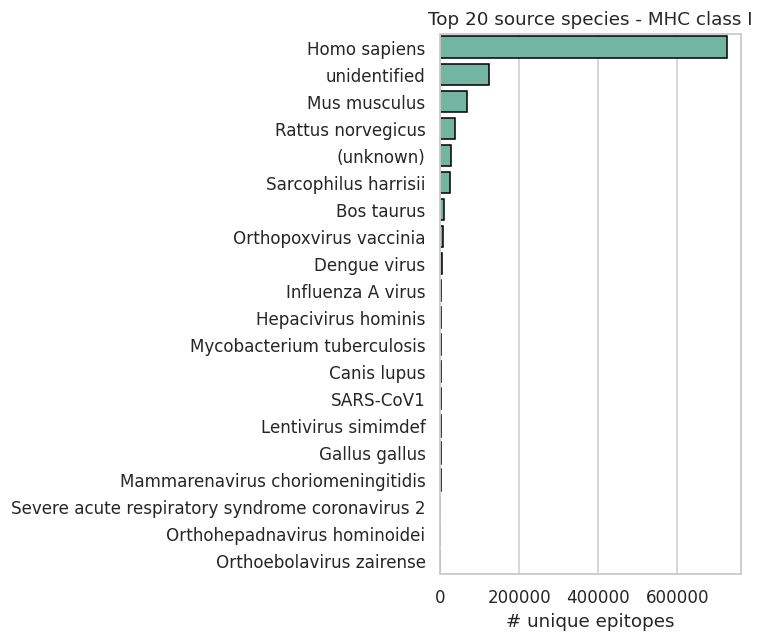

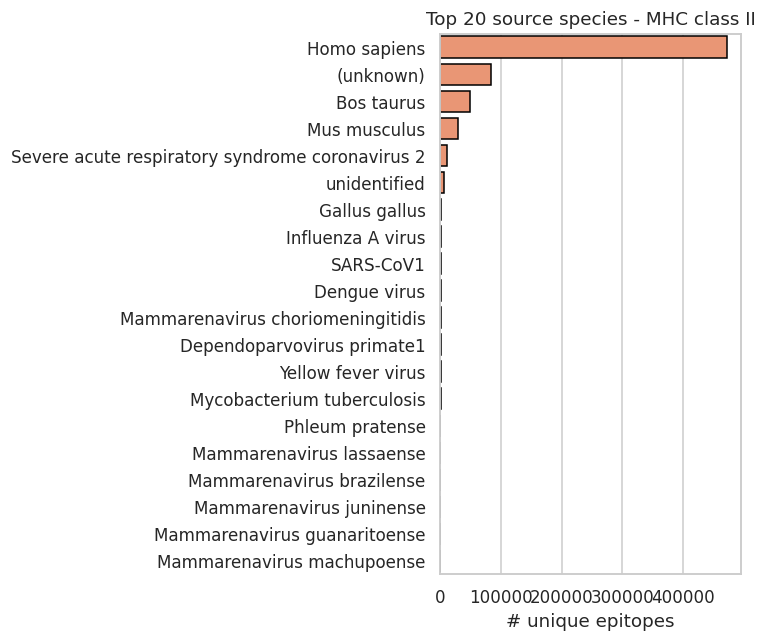

In [34]:

# Plot 1 — MHC Class I
fig1, ax1 = plt.subplots(figsize=(7, 6))
s1 = top_species("I").head(TOP)
sns.barplot(x=s1.values, y=s1.index, ax=ax1, color="#66c2a5",
             edgecolor="black", linewidth=1)
ax1.set(title=f"Top {TOP} source species - MHC class I",
        xlabel="# unique epitopes", ylabel="")
plt.tight_layout()
plt.show()

# Plot 2 — MHC Class II
fig2, ax2 = plt.subplots(figsize=(7, 6))
s2 = top_species("II").head(TOP)
sns.barplot(x=s2.values, y=s2.index, ax=ax2, color="#fc8d62",
             edgecolor="black", linewidth=1)
ax2.set(title=f"Top {TOP} source species - MHC class II",
        xlabel="# unique epitopes", ylabel="")
plt.tight_layout()
plt.show()

## 4. How concentrated is the data?

A large share of epitopes typically comes from a handful of well-studied organisms (e.g. *Homo sapiens* self-peptides, common viruses). Quick look at the cumulative share.

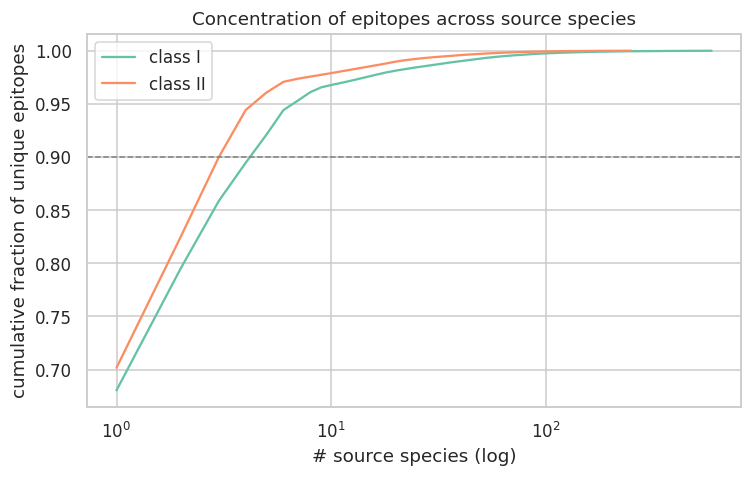

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for cls, color in zip(["I", "II"], ["#66c2a5", "#fc8d62"]):
    s = top_species(cls)
    cum = np.cumsum(s.values) / s.values.sum()
    ax.plot(range(1, len(cum) + 1), cum, label=f"class {cls}", color=color)
ax.set(xscale="log", xlabel="# source species (log)", ylabel="cumulative fraction of unique epitopes",
       title="Concentration of epitopes across source species")
ax.axhline(0.9, ls="--", c="gray", lw=1)
ax.legend(); plt.tight_layout(); plt.show()

## Summary

See the printed counts above for the headline numbers (unique class I vs class II epitopes, number of source species, and the top organisms). The data is dominated by a small number of heavily-studied organisms — read the concentration curve in section 4 for how skewed it is.

### Now we filter dataset to only look into Human host and pathogen only

In [ ]:

# Re-stream including the Host column (43) + source organism IRI (26) for later taxonomy use
USECOLS = [11, 23, 25, 26, 43, 111]
NAMES   = ["peptide", "source_organism", "species", "species_iri", "host", "mhc_class"]

# Non-pathogen source species to drop (self / animal models / food animals).
# Host is already human, so "Homo sapiens" source == self/tumor peptides.
NON_PATHOGEN = {
    "Homo sapiens",          # human (self/tumor)
    "Mus musculus",          # mouse
    "Rattus norvegicus",     # rat
    "Bos taurus",            # cattle
    "Sus scrofa",            # pig
    "Gallus gallus",         # chicken
    "Canis lupus",           # dog/wolf
    "Sarcophilus harrisii",  # Tasmanian devil
    "Macaca mulatta",        # rhesus macaque
    "Ovis aries",            # sheep
    "Equus caballus",        # horse
    "Oryctolagus cuniculus", # rabbit
     "unidentified", 
     "(unknown)",
}

seen = set()
reader = pd.read_csv("IEDB/mhc_ligand_full.csv", header=None, skiprows=2,
                     usecols=USECOLS, names=NAMES, dtype=str,
                     chunksize=200_000, low_memory=False)
for ch in reader:
    ch = ch[ch["host"] == "Homo sapiens (human)"]                 # human host
    ch = ch.dropna(subset=["peptide"])
    ch["species"] = ch["species"].fillna("(unknown)")
    ch = ch[~ch["species"].isin(NON_PATHOGEN)]                    # pathogens only
    ch["mhc_class"] = ch["mhc_class"].fillna("(none)")
    seen.update(ch[["mhc_class", "peptide", "species", "species_iri"]]
                .itertuples(index=False, name=None))


In [11]:

up = pd.DataFrame(seen, columns=["mhc_class", "peptide", "species", "species_iri"])
print("human-host pathogen epitopes:", len(up))
print(up.groupby("mhc_class")["peptide"].nunique())
print(up[up.mhc_class == "I"].groupby("species")["peptide"].nunique().sort_values(ascending=False).head(20))




human-host pathogen epitopes: 63672
mhc_class
I                35121
II               26364
non classical      479
Name: peptide, dtype: int64
species
Orthopoxvirus vaccinia                             7189
Dengue virus                                       4861
SARS-CoV1                                          1645
Hepacivirus hominis                                1616
Mycobacterium tuberculosis                         1587
Influenza A virus                                  1305
Severe acute respiratory syndrome coronavirus 2    1113
Orthoebolavirus zairense                            877
Orthohepadnavirus hominoidei                        814
Human betaherpesvirus 5                             754
Plasmodium falciparum                               688
human gammaherpesvirus 4                            607
Deltaretrovirus priTlym1                            544
Lentivirus humimdef1                                469
Human alphaherpesvirus 1                            460
Mammarena

In [12]:
up.to_csv("/lustre/scratch126/gengen/teams_v2/marks/dp31/tcr-bench/IEDB/iedb_human_pathogen_epitopes.csv", index=False)

,mhc_class,peptide,species,species_iri
0,II,LRGSETTVTERIFRQ,Mammarenavirus choriomeningitidis,http://purl.obolibrary.org/obo/NCBITaxon_3052303
1,II,SRAFLTANKNKPGVKT,Coxiella burnetii,http://purl.obolibrary.org/obo/NCBITaxon_777
2,I,HYAFVGVMYNL,Yellow fever virus,http://purl.obolibrary.org/obo/NCBITaxon_11089
3,II,KTQSLLIVNNATNVV,Severe acute respiratory syndrome coronavirus 2,http://purl.obolibrary.org/obo/NCBITaxon_2697049
4,II,IDQYLYYLSRTNTPSGTTTQS,Dependoparvovirus primate1,http://purl.obolibrary.org/obo/NCBITaxon_1511891
